In [1]:
###### START ######

import pandas as pd
import statsmodels.api as sm

# Load the dataset
file_path = 'FinalProjectDataset.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset for review
data.head()

,disc_hire,gender,age,edu_cat,mariage,emp_fin,income_quartile,birth_region,health,disability,residence,disc_wage,disc_jobedu,disc_promotion,disc_resign,disc_edu,disc_home,disc_social
0,1.0,0,3,1,2,0,0,0,1,0,1,1,0,0,0,0,0,0
1,0.0,1,3,1,2,1,1,0,2,0,1,0,0,0,0,0,0,0
2,0.0,1,1,2,0,1,1,0,2,0,1,0,0,0,0,0,0,0
3,0.0,1,1,2,1,0,3,0,1,0,1,0,0,0,0,0,0,0
4,1.0,0,3,0,1,0,1,0,2,0,1,0,0,0,0,0,0,1


In [2]:
####### QUESTION 1  #######

from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

# Filter the dataset to include only participants with 'disc_hire' value as 0 or 1
filtered_data = data[data['disc_hire'].isin([0, 1])]

# Define the response variable and explanatory variables
response = filtered_data['disc_hire']
explanatory = filtered_data.drop('disc_hire', axis=1)

# Fit a logistic regression model
logit_model = sm.Logit(response, sm.add_constant(explanatory))
result = logit_model.fit()

# Display the summary of the logistic regression model
result.summary()


Optimization terminated successfully.
         Current function value: 0.310260
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              disc_hire   No. Observations:                 3479
Model:                          Logit   Df Residuals:                     3461
Method:                           MLE   Df Model:                           17
Date:                Fri, 15 Dec 2023   Pseudo R-squ.:                  0.3751
Time:                        03:20:16   Log-Likelihood:                -1079.4
converged:                       True   LL-Null:                       -1727.2
Covariance Type:            nonrobust   LLR p-value:                3.918e-265
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.6120      0.273     -9.572      0.000      -3.147      -2.077
gender             -0.0521      0.120     -0.434      0.664      -0.287       0.183
age                 0.1300      0.062      2.084      0.037       0.008       0.252
edu_cat            -0.0691      0.092     -0.749      0.454      -0.250       0.112
mariage            -0.4246      0.134     -3.175      0.001      -0.687      -0.163
emp_fin             0.4897      0.133      3.679      0.000       0.229       0.751
income_quartile    -0.2322      0.057     -4.040      0.000      -0.345      -0.120
birth_region       -0.1042      0.149     -0.700      0.484      -0.396       0.187
health              0.1810      0.087      2.085      0.037       0.011       0.351
disability          0.2605      0.329      0.791      0.429      -0.385       0.905
residence           0.0396      0.012      3.182      0.001       0.015       0.064
disc_wage           3.2172      0.132     24.329      0.000       2.958       3.476
disc_jobedu         0.1118      0.114      0.983      0.325      -0.111       0.335
disc_promotion      0.1990      0.107      1.860      0.063      -0.011       0.409
disc_resign         0.1593      0.097      1.645      0.100      -0.031       0.349
disc_edu           -0.0154      0.142     -0.109      0.914      -0.294       0.263
disc_home          -0.1022      0.245     -0.416      0.677      -0.583       0.379
disc_social         1.1763      0.169      6.956      0.000       0.845       1.508
===================================================================================
"""

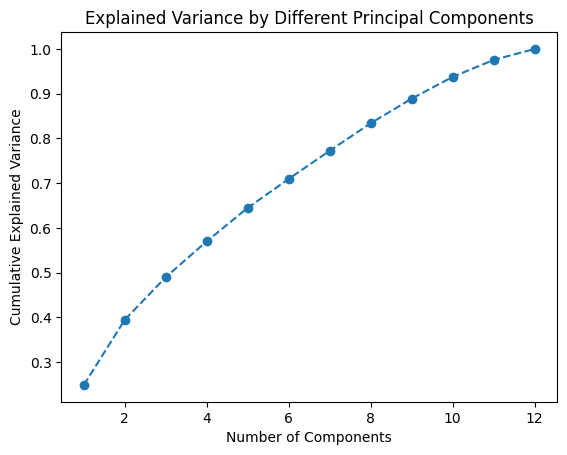

                      PC1       PC2       PC3       PC4       PC5       PC6
gender           0.167435  0.016164 -0.791322  0.043433  0.420158 -0.208187
age              0.322990 -0.596856  0.336981 -0.404556 -0.060399 -0.204470
edu_cat         -0.512316  0.596214  0.037254  0.090483  0.126472  0.204848
emp_fin          0.430839 -0.377448 -0.342500  0.225503 -0.220718  0.018825
income_quartile -0.443912  0.328414  0.136127 -0.407821  0.348345 -0.389241
health           0.272044 -0.494769 -0.041915 -0.221880  0.521121  0.237606
disability       0.143707 -0.201233  0.473983  0.686229  0.440559 -0.143829
disc_wage        0.581898  0.194007  0.095080 -0.017882 -0.024730 -0.405027
disc_jobedu      0.769294  0.312607  0.007479 -0.020416 -0.065548 -0.044124
disc_promotion   0.767150  0.349258 -0.004350  0.007794 -0.058350 -0.039403
disc_resign      0.559861  0.466811  0.109063 -0.014171  0.088114  0.019949
disc_edu         0.536045  0.158167  0.140313 -0.221308  0.221716  0.503064


In [7]:
######## QUESTION 2 ########

import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load your dataset
data = pd.read_csv('FinalProjectDataset.csv')

# Select the 12 specified variables
selected_columns = ['gender', 'age', 'edu_cat', 'emp_fin', 'income_quartile', 
                    'health', 'disability', 'disc_wage', 'disc_jobedu', 
                    'disc_promotion', 'disc_resign', 'disc_edu']
data_selected = data[selected_columns]

# Standardize the data
scaler = StandardScaler()
data_std = scaler.fit_transform(data_selected)

# Apply PCA
pca = PCA()
principalComponents = pca.fit_transform(data_std)

# Plotting the Cumulative Summation of the Explained Variance
plt.figure()
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Explained Variance by Different Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

# To decide the number of components, look at the plot and identify where the curve starts to plateau
# For instance, if you choose n_components:
n_components = 6 # choose based on the plot

# Re-run PCA with the chosen number of components
pca_final = PCA(n_components=n_components)
principalComponents_final = pca_final.fit_transform(data_std)

# The loadings of the components can be obtained as follows
loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)

# Convert loadings to a DataFrame for easier interpretation
loading_matrix = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(n_components)], 
                              index=data_selected.columns)

# Now you can interpret each component based on the loading scores
print(loading_matrix)


c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will cha

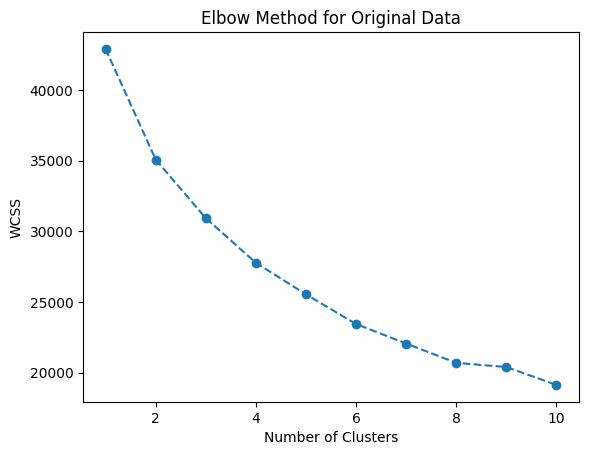

c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will cha

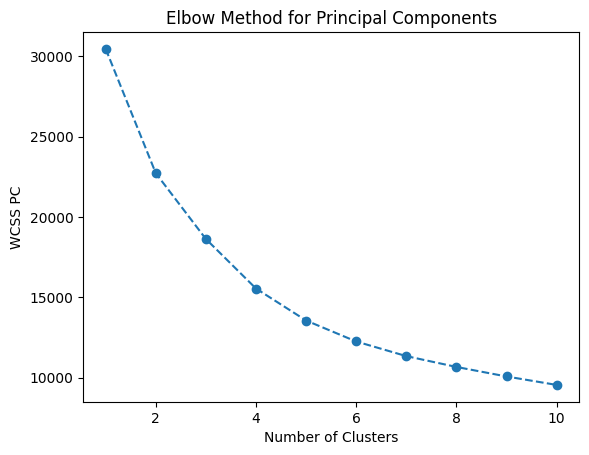

Centroids for Original Data:
         gender       age   edu_cat   emp_fin  income_quartile    health  \
0  1.000000e+00  1.238938  1.469027  0.144121         2.113780  1.247788   
1  4.316290e-01  2.958383  0.360285  0.529132         1.189061  1.744352   
2  4.934211e-01  2.585526  0.664474  0.381579         1.118421  1.684211   
3 -3.330669e-16  1.730825  1.537627  0.032562         2.096961  1.222865   
4  5.251572e-01  1.993711  0.805031  0.477987         1.261006  1.405660   
5  1.630435e-01  2.641304  0.630435  0.369565         1.108696  1.750000   

     disability  disc_wage  disc_jobedu  disc_promotion  disc_resign  disc_edu  
0  1.387779e-17   0.108723     0.026549        0.103666     0.122630  0.008850  
1  6.938894e-18   0.172414     0.045184        0.105826     0.030916  0.020214  
2  3.469447e-18   0.644737     1.243421        1.375000     1.171053  1.953947  
3  1.040834e-17   0.072359     0.018813        0.078871     0.141100  0.005065  
4  3.469447e-18   0.591195     1.

c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [9]:
######## QUESTION 3 ########

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use the elbow method to find the optimal number of clusters for the original data
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(data_std)
    wcss.append(kmeans.inertia_)

# Plot the WCSS to visualize the elbow
plt.figure()
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Original Data')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Repeat the elbow method for the principal component scores
wcss_pc = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(principalComponents_final)
    wcss_pc.append(kmeans.inertia_)

# Plot the WCSS for the principal components
plt.figure()
plt.plot(range(1, 11), wcss_pc, marker='o', linestyle='--')
plt.title('Elbow Method for Principal Components')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS PC')
plt.show()

# Choose the number of clusters (n_clusters) based on the elbow plots
n_clusters = 6# determined from the elbow plot

# Perform K-means clustering with the chosen number of clusters on original data
kmeans_original = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
clusters_original = kmeans_original.fit_predict(data_std)

# Perform K-means clustering with the chosen number of clusters on principal components
kmeans_pc = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
clusters_pc = kmeans_pc.fit_predict(principalComponents_final)

# Describe the clusters by examining the centroids
centroids_original = kmeans_original.cluster_centers_
centroids_pc = kmeans_pc.cluster_centers_

# Convert centroids to a DataFrame for easier interpretation
centroids_original_df = pd.DataFrame(scaler.inverse_transform(centroids_original), columns=data_selected.columns)
centroids_pc_df = pd.DataFrame(centroids_pc, columns=[f'PC{i+1}' for i in range(n_components)])

# Now you can describe each cluster by looking at the values of the centroids
print("Centroids for Original Data:")
print(centroids_original_df)
print("\nCentroids for Principal Components:")
print(centroids_pc_df)


In [10]:
######## QUESTION 4 ########

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve

# Assuming `data` is your full dataset
# Filter out the participants with 'NA' for 'disc_hire' and prepare the data for modeling
data_model = data[data['disc_hire'].notna()]
X = data_model.drop(['disc_hire'], axis=1)
y = data_model['disc_hire'].astype('int')  # Ensure the target is integer

# Splitting data into training and test sets for cross-validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a Random Forest Classifier and a grid for cross-validation
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, 15]}

# Conduct Grid Search to find the optimal parameters for Random Forest
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='roc_auc')
grid_search_rf.fit(X_train, y_train)
rf_best_params = grid_search_rf.best_params_
rf_best_score = grid_search_rf.best_score_

# Define a Penalized Logistic Regression with Lasso penalty
logreg_cv = LogisticRegressionCV(cv=5, penalty='l1', solver='liblinear', scoring='roc_auc', random_state=42, max_iter=1000)
logreg_cv.fit(X_train, y_train)
logreg_best_score = logreg_cv.scores_[1].mean(axis=0).max()

# Comparing the AUC scores to select the best model
best_model = grid_search_rf.best_estimator_ if rf_best_score > logreg_best_score else logreg_cv

# Predicting the probabilities on the test set using the best model
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Calculating the ROC curve and determining the optimal threshold
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# Predicting on the data of the 97 participants who responded 'NA'
NA_data = data[data['disc_hire'].isna()]
NA_pred_prob = best_model.predict_proba(NA_data.drop(['disc_hire'], axis=1))[:, 1]
NA_pred = (NA_pred_prob >= optimal_threshold).astype(int)

# Analyzing the predicted distribution between males and females
NA_data['predicted_disc_hire'] = NA_pred
predicted_distribution = NA_data.groupby('gender')['predicted_disc_hire'].value_counts(normalize=True).unstack()

# This gives you the proportion of predicted 'Yes' responses for hiring discrimination for each gender
print(predicted_distribution)


predicted_disc_hire         0         1
gender                                 
0                    0.515625  0.484375
1                    0.090909  0.909091


C:\Users\Munim Hasan Wasi\AppData\Local\Temp\ipykernel_2708\713749784.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NA_data['predicted_disc_hire'] = NA_pred


In [11]:
######## QUESTION 5 ########

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Combine the original responses with the predicted responses for 'NA' participants
data['disc_hire_combined'] = data['disc_hire']
na_indices = data['disc_hire'].isna()
data.loc[na_indices, 'disc_hire_combined'] = NA_data['predicted_disc_hire']

# Map the combined responses to the corresponding groups
response_mapping = {0: 'No', 1: 'Yes', 'NA': 'NA'}
data['disc_hire_group'] = data['disc_hire_combined'].map(response_mapping)

# Conduct an ANOVA to test for overall differences in self-rated health among the four groups
lm = ols('health ~ C(disc_hire_group)', data=data).fit()
anova_results = sm.stats.anova_lm(lm, typ=2)

# If the overall ANOVA is significant, perform pairwise comparisons
if anova_results['PR(>F)'][0] < 0.05:
    tukey_results = pairwise_tukeyhsd(data['health'], data['disc_hire_group'], alpha=0.05)
    print(tukey_results.summary())
else:
    print("No significant differences found among the four groups.")

# Print the ANOVA table
print(anova_results)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
    No    Yes   0.1504   0.0 0.0957 0.2051   True
-------------------------------------------------
                         sum_sq      df          F        PR(>F)
C(disc_hire_group)    13.363278     1.0  29.030191  7.586418e-08
Residual            1645.196006  3574.0        NaN           NaN
